# Exercise 9: Comparing data to predictions (20 points)

The exercise this week will allow you to gain some experience with comparing data to predictions, such as how well two variables are correlated.

### Tips for completing this exercise

- Use **exactly** the same variable names as in the instructions because your answers will be automatically graded, and the tests that grade your answers rely on following the same formatting or variable naming as in the instructions.
- **Please do not**:

    - **Change the file names**. Do all of your editing in the provided `Exercise-9-problems-1-3.ipynb` file (this file).
    - **Change the existing cell types**. You can add cells, but changing the cell types for existing cells (from code to markdown, for example) will also cause the automated grader to fail. 

## Problem 1: Linear data regression for detecting changing climate (8.5 points)

For this problem we will again use the NOAA climate data from previous exercises with a slight twist. As a reminder, you will be working with a climate data file from the [US National Oceanographic and Atmospheric Administration (NOAA) climate database](https://www.ncdc.noaa.gov/cdo-web/). In order to jump right into things, we have provided you with [a data file that has already been processed](data/seasonal-temps.csv) containing the means and standard deviations of seasonal temperatures (in Celsius) for winter and summer for the years 1966-2022. The first 5 lines of the data file are:

```
Year,Jan mean,Jan std,May temp,May std
1966,26.741935,0.478730,28.706452,1.139279
1967,26.119355,1.172865,29.219355,0.480569
1968,26.467742,0.813383,29.135484,0.526339
1969,26.100000,0.643428,29.016129,0.873726
```

Your task is to load this data and use a least squares regression to fit trendlines to the temperature data.

### Scores for this problem

**Your score on this problem will be based on following criteria**:

- Reading in the data file for this exercise
- Properly converting the linear regressions formulas to a Python function and adding it to your `gdam_functions.py` script file from Exercise 8
- Calculating the least-squares regression lines for "summer" (May) and winter (January), for two different time periods
- Plotting your results
- Including comments that explain what most lines in the code do
- Uploading your notebook **and script file** to your GitHub repository for this week's exercise

### Part 1: Reading the data file (1 point)

Your first task is to read in [the data file for this problem](data/seasonal-temps.csv).

- For this, you should use the Pandas `read_csv()` funtion to read in the data file [data/seasonal-temps.csv](data/seasonal-temps.csv) into the variable `data`
    - You do not need to skip any rows or specify an index column

In [1]:
# Import Pandas and NumPy
import pandas as pd
import numpy as np

#Import and read the data file
fp = 'data/seasonal-temps-mac.csv'
data = pd.read_csv(fp)

In [2]:
# This test should print the first row of the data file
print("First row of the DataFrame:\n", data.head(1))


First row of the DataFrame:
    Year   Jan mean  Jan std   May mean   May std
0  1966  26.741935  0.47873  28.706452  1.139279


### Part 2: A linear regression function (1.5 points)

Your next task in this problem is to create a function that calculates the slopes `B` and *y*-intercepts `A` for [unweighted linear regression lines](https://introqg-site.readthedocs.io/en/latest/notebooks/L2/least-squares.html). As you may recall from the lesson, `A` and `B` can be calculated as

\begin{equation}
  \Large
  A = \frac{\sum{x^2} \sum{y} - \sum{x} \sum{x y}}{\Delta}
\end{equation}

and

\begin{equation}
  \Large
  B = \frac{N \sum{x y} - \sum{x} \sum{y}}{\Delta},
\end{equation}

where

\begin{equation}
  \Large
  \Delta = N \sum{x^2} - \left(\sum{x} \right)^2.
\end{equation}

- Create a function `linregress` in your `gdam_functions.py` script file that returns the slope `B` and *y*-intercept `A` for a regression line for data `x` and `y`.
    - **NOTE**: You can return both `A` and `B` in the same `return` statement by separating the values with a comma
    - **NOTE**: You may need to restart your kernel in order for the new function to be imported. You may receive an `ImportError` otherwise.

In [3]:
# Import your new function below using the format "from gdam_functions import linregress"

from gdam_functions import linregress 

In [4]:
# These visible tests with fake data should work
import numpy as np
from unittest import TestCase
# Create a shortcut that works like the old one
assert_equal = TestCase().assertEqual

# Fake data for linregress tests
x1 = np.array([1.0, 2.0])
y1 = np.array([1.0, 2.0])
x2 = np.array([1.0, 2.0, 2.5, 3.6, 4.2, 5.9])
y2 = np.array([1.0, 2.0, 2.7, 3.1, 4.7, 5.7])

# Fake line slopes, intercepts
a1, b1 = linregress(x1, y1)
a2, b2 = linregress(x2, y2)

# Print results
print(f"Slope and intercept for dataset 1: {b1:.4f} and {a1:.4f}.")
print(f"Slope and intercept for dataset 2: {b2:.4f} and {a2:.4f}.")

# Check that the linregress function works
assert_equal(a1, 0.0)
assert_equal(b1, 1.0)
assert_equal(round(a2, 4), 0.0799)
assert_equal(round(b2, 4), 0.975)

Slope and intercept for dataset 1: 1.0000 and 0.0000.
Slope and intercept for dataset 2: 0.9750 and 0.0799.


### Part 3: Calculating seasonal regression lines (1.5 points)

Now we can calculate the slopes and y-intercepts for our weather data to determine how summer and winter temperatures have varied over the observation period. We'll do this for two time ranges: The **entire observation period** and the **last 20 years (2003-2022)**.

- Use your `linregress` function to calculate the slopes and intercepts for summer and winter for the time periods mentioned above (the entire range of years, and 2003-2022).
You should name these values as follows:
    - Entire range of years: `A_winter` and `B_winter` for winter, `A_summer` and `B_summer` for summer
    - Last 20 years: `A_winter20` and `B_winter20` for winter, `A_summer20` and `B_summer20` for summer

**Hint**: In this problem, `x` will be your time data, and `y` will be your temperatures.

In [5]:
# Calculation for the linear regression for the winter and summer seasons in all years and in the last 20 years
A_winter, B_winter = linregress (data['Year'], data['Jan mean'])
A_summer, B_summer = linregress (data['Year'], data['May mean'])
A_winter20, B_winter20 = linregress (data['Year'].loc[34:53], data['Jan mean'].loc[34:53])
A_summer20, B_summer20 = linregress (data['Year'].loc[34:53], data['May mean'].loc[34:53])

In [6]:
###### This test should work
print(f"Winter (all years) slope: {B_winter:.5f}. Expected value: 0.00536.")
print(f"Winter (all years) intercept {A_winter:.1f}. Expected value: 16.0")


Winter (all years) slope: 0.00536. Expected value: 0.00536.
Winter (all years) intercept 16.0. Expected value: 16.0


In [7]:
# This test should work
print(f"Summer (last 20 years) slope: {B_summer20:.5f}. Expected value: 0.02437.")
print(f"Summer (last 20 years) intercept: {A_summer20:.1f}. Expected value: -19.8.")


Summer (last 20 years) slope: 0.02437. Expected value: 0.02437.
Summer (last 20 years) intercept: -19.8. Expected value: -19.8.


### Part 4: Plotting your results (4.5 points)

Your last coding task for this problem is to create some plots of your seasonal temperature data and their trendlines. An example of the types of plots you should create are below.
**Note**: You could create two separate plots for the different time periods, and not use subplots as shown in the example below.

![Temperature trends in Helsinki](img/temp-slopes.png)

- Create 2 plots of the seasonal temperature data: (**1**) one for the entire time covered in the data and (**2**) another for the last 20 years of data
    - Plot the seasonal average temperature data as a Pandas scatter plot with error bars showing the standard deviation in seasonal temperature
    - Also plot the regression lines for each season as well to compare to the yearly temperature data. You may want to consult [the hints for this week's exercise](https://geo-python-upd.readthedocs.io/en/latest/lessons/L9/exercise-9.html#general-hints-for-exercise-9) about how to plot the regression lines.
    - Plot the temperature data for both seasons on the same plot, using a warm color (e.g., red) for summer and a cool color (e.g., blue) for winter. You can find some convenient color names you can use in the [Matplotlib documentation online](https://matplotlib.org/stable/gallery/color/named_colors.html).
    - Be sure to set the figure size to be slightly larger, as was done in Exercise 1
- Include axis labels, a title and a legend for each plot, as well as text displaying the slope of the regression lines for both the summer and winter seasons
    - If your plot legend is empty, be sure that you have a label included for the scatter plot for each season with the text name of that season
- Add figure captions in the Markdown cell below each Python cell for your plots that describe the plots as if they were in a scientific journal article

Text(1967, 27.5, 'Slope (Winter): \n 0.0054')

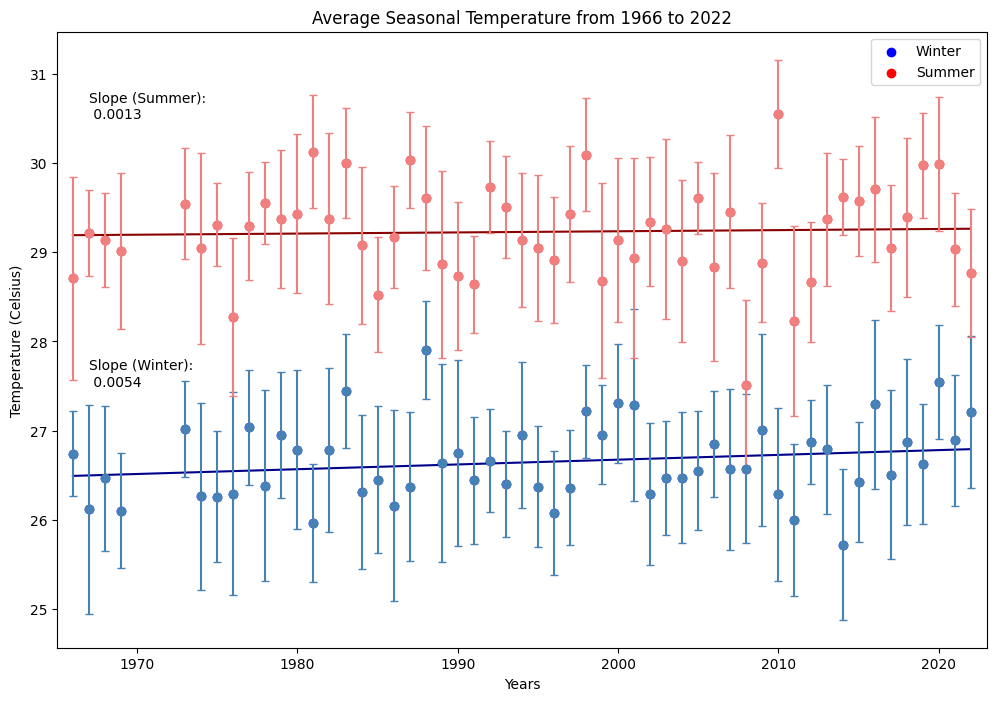

In [28]:
import matplotlib.pyplot as plt

# Plots the base of the graph and axes
fig1, ax = plt.subplots(1, 1, figsize=(12,8))

# Data set 1 for winter (all years)
xw = data['Year']
yw = data['Jan mean']

# Data set 2 for summer (all years)
xs = data['Year']
ys = data['May mean']

# Scatter Plots
ax.scatter(xw, yw, color='blue', label='Winter')
ax.scatter(xs, ys, color='red', label='Summer')

# Trendline and equation of a line plot
ax.plot([xw.min(), xw.max()], [(A_winter + B_winter*xw.min()), (A_winter + B_winter*xw.max())], color='darkblue')
ax.plot([xs.min(), xs.max()], [(A_summer + B_summer*xs.min()), (A_summer + B_summer*xs.max())], color='darkred')

# Figure elements
ax.legend() # legend
ax.set_xlabel('Years') #x-axis label
ax.set_ylabel('Temperature (Celsius)') #y-axis label
ax.set_xlim (1965, 2023) #x-axis limit
plt.title('Average Seasonal Temperature from 1966 to 2022') #figure title
ax.errorbar(xw, yw, yerr=data['Jan std'], color='steelblue', fmt = 'o', capsize = 3) # error bars
ax.errorbar(xs, ys, yerr=data['May std'], color='lightcoral', fmt = 'o', capsize = 3)

ax.text(1967, 30.5, f"Slope (Summer): \n{B_summer: .4f}") #slope value
ax.text(1967, 27.5, f"Slope (Winter): \n{B_winter: .4f}")

*Figure 1.* Average seasonal temperatures from 1966 to 2022. The red plot is for suumer and the blue plot is for winter. 

Text(2003, 27.5, 'Slope (Winter): \n 0.0283')

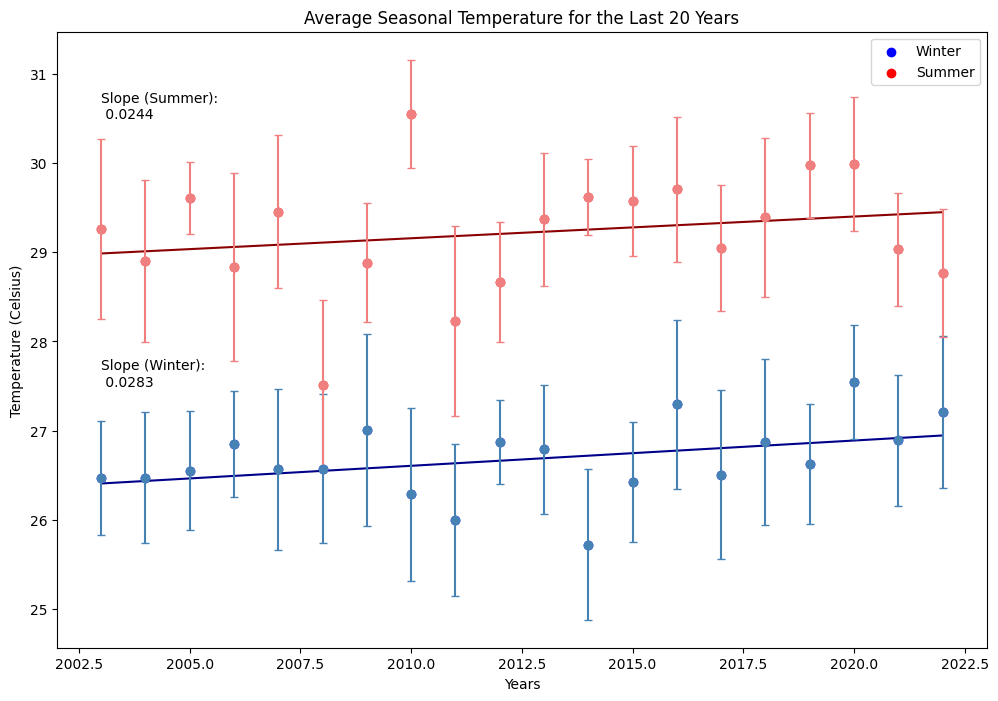

In [30]:
# plots the base of the graph and axes
fig1, ax1 = plt.subplots(1, 1, figsize=(12,8))

# Data set 1 for winter (last 20 years)
xw1 = data['Year'].loc[34:54]
yw1 = data['Jan mean'].loc[34:54]

# Data set 2 for summer (last 20 years)
xs1 = data['Year'].loc[34:54]
ys1 = data['May mean'].loc[34:54]

# Scatter plots
ax1.scatter(xw1, yw1, color='blue', label='Winter')
ax1.scatter(xs1, ys1, color='red', label='Summer')

# Trendline and equation of a line plots
ax1.plot([xw1.min(), xw1.max()], [(A_winter20 + B_winter20*xw1.min()), (A_winter20 + B_winter20*xw1.max())], color='darkblue')
ax1.plot([xs1.min(), xs1.max()], [(A_summer20 + B_summer20*xs1.min()), (A_summer20 + B_summer20*xs1.max())], color='darkred')

# Figure elements
ax1.legend() # legend
ax1.set_xlabel('Years') #x-axis label
ax1.set_ylabel('Temperature (Celsius)') #y-axis label
ax1.set_xlim (2002, 2023) #x-axis limit
plt.title('Average Seasonal Temperature for the Last 20 Years') #fligure title
ax1.errorbar(xw1, yw1, yerr=data['Jan std'].loc[34:54], color='steelblue', fmt = 'o', capsize = 3) #error bars
ax1.errorbar(xs1, ys1, yerr=data['May std'].loc[34:54], color='lightcoral', fmt = 'o', capsize = 3)
ax1.text(2003, 30.5, f"Slope (Summer): \n{B_summer20: .4f}") #slope value
ax1.text(2003, 27.5, f"Slope (Winter): \n{B_winter20: .4f}")

*Figure 2.* Average seasonal temperatures from 2003 to 2022. The red plot is for suumer and the blue plot is for winter.

## Problem 2 - Linear correlation: Is a line a good fit for our data? (6 points)

In Problem 1 we used least squares regressions to calculate lines that best fit our data. One thing we did not consider, however, was whether a line was a suitable model for our data. To consider this another way, we could ask ourselves how well do our data plot on a line? This question will be the focus of Problem 2, where we will calculate the linear correlation coefficient $r$ to explore how well our data fall on a line. Notably, in doing this we will *not* consider the standard deviations in our seasonal temperatures, only the mean values for the different seasons.

### Scores for this problem

**Your score on this problem will be based on following criteria**:

- Properly converting the linear correlation coefficient formula to a Python function and adding it to your `gdam_functions.py` script file.
- Calculating linear corelation coefficients for summer and winter and for the two different time periods
- Plotting your results
- Including comments that explain what most lines in the code do
- Uploading your notebook and modified script file to your GitHub repository for this week's exercise

### Part 1: A correlation coefficient function (1.5 points)

As we have seen in this week's lesson, the correlation coefficient $r$ can be used to determine how well two variables are linearly correlated with one another. In other words, how well does a line relate the two. Mathematically, we can define the correlation coefficient $r$ as

\begin{equation}
  \Large
  r = \frac{\sum{\left(x_{i} - \bar{x} \right)\left(y_{i} - \bar{y} \right)}}{\sqrt{\sum{\left(x_{i} - \bar{x} \right)^2} \sum{\left(y_{i} - \bar{y} \right)^2}}},
\end{equation}

where $x_{i}$ is the $i$th value along the $x$-axis, $\bar{x}$ is the mean of the values on the $x$-axis, and similarly for the values of $y$.

Your task in this part of the problem is to make a function for calculating $r$.

- Create a function `pearson()` in your `gdam_functions.py` script file that returns the correlation coefficient $r$ between two variables `x` and `y`

In [31]:
#impprt the 'pearson function from 'gdam_functions'
from gdam_functions import pearson

In [32]:
# These visible tests with fake data should work
from unittest import TestCase
# Create a shortcut that works like the old one
assert_equal = TestCase().assertEqual

# Fake data for pearson tests
x1 = np.array([1.0, 2.0, 3.0])
y1 = np.array([1.0, 2.0, 2.1])
x2 = np.array([1.0, 2.0, 2.5, 3.6, 4.2, 5.9])
y2 = np.array([5.7, 4.2, 3.6, 5.4, 2.0, 1.0])

# Fake correlation coefficients
r1 = pearson(x1, y1)
r2 = pearson(x2, y2)

# Print results
print(f"Correlation coefficient for dataset 1: {r1:.4f}.")
print(f"Correlation coefficient for dataset 2: {r2:.4f}.")

# Check that the pearson function works
assert_equal(round(r1, 4), 0.9042)
assert_equal(round(r2, 4), -0.8156)

Correlation coefficient for dataset 1: 0.9042.
Correlation coefficient for dataset 2: -0.8156.


### Part 2: Calculating correlation coefficients (1.5 points)

Next, we can calculate the correlation coefficients for our weather data.

- Calculate correlation coefficients for the summer and winter and for both time ranges (the entire range of years, and 2003-2022) using your `pearson()` function.
You should name these values as follows:
    - Entire range of years: `r_winter` for winter and `r_summer` for summer
    - Last 20 years: `r_winter20` for winter, `r_summer20` for summer

In [33]:
# Calculation for the correlation coefficients for the winter and summer seasons in all years and in the last 20 years
r_winter = pearson(data['Year'], data['Jan mean'])
r_summer = pearson(data['Year'], data['May mean'])
r_winter20 = pearson (data['Year'].loc[34:53], data['Jan mean'].loc[34:53])
r_summer20 = pearson (data['Year'].loc[34:53], data['May mean'].loc[34:53])

In [34]:
# This test should work
print(f"Your winter (all years) correlation coefficient: {r_winter:.4f}. Expected value: 0.1966.")


Your winter (all years) correlation coefficient: 0.1966. Expected value: 0.1966.


In [35]:
# This test should work
print(f"Your summer (last 20 years) correlation coefficient: {r_summer20:.4f}. Expected value: 0.2144.")


Your summer (last 20 years) correlation coefficient: 0.2144. Expected value: 0.2144.


### Part 3: Plotting your results, round 2 (3 points)

Now we can generate a pair of plots showing the data along with the calculated $r$ values.

- Create 2 plots of the seasonal temperature data: (**1**) one for the entire time covered in the data and (**2**) another for the last 20 years of data
    - Plot the seasonal average temperature data as a Pandas scatter plot **without** error bars for the standard deviation in seasonal temperature
    - Also include the regression lines for each season from Problem 1 to compare to the yearly temperature data. You may want to consult [the hints for this week's exercise](https://introqg-site.readthedocs.io/en/latest/lessons/L2/exercise-2.html) about how to plot the regression lines.
    - Plot the temperature data for both seasons on the same plot, using a warm color (e.g., red) for summer and a cool color (e.g., blue) for winter. You can find some convenient color names you can use in the [Matplotlib documentation online](https://matplotlib.org/stable/gallery/color/named_colors.html).
    - Be sure to set the figure size to be slightly larger, as was done in Exercise 8
- Include axis labels, a title and a legend for each plot, as well as text displaying the correlation coefficients for both the summer and winter seasons
    - If your plot legend is empty, be sure that you have a label included for the scatter plot for each season with the text name of that season
- Add figure captions in the Markdown cell below each Python cell for your plots that describe the plots as if they were in a scientific journal article

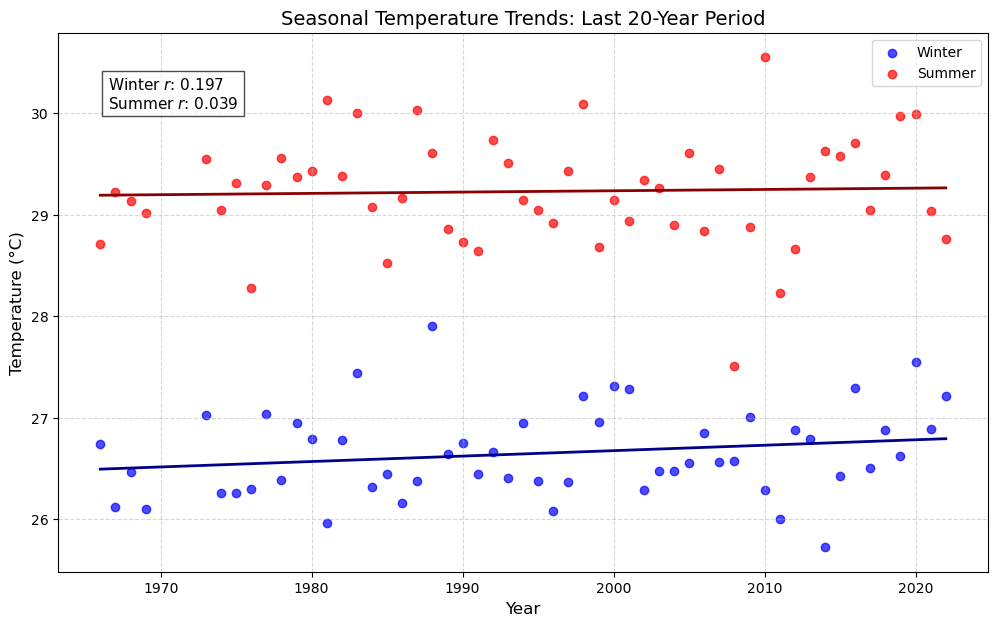

In [ ]:
# Plot for all years goes here


import matplotlib.pyplot as plt
import numpy as np

# Define the subset for all years

fig, ax3 = plt.subplots(figsize=(12, 7))

# Scatter plots for all of the years
ax3.scatter(data['Year'], data['Jan mean'], color='blue', label='Winter', alpha=0.7)
ax3.scatter(data['Year'], data['May mean'], color='red', label='Summer', alpha=0.7)

# Calculate and include regression lines for the subset
# Winter regression (all years)
slope_w, intercept_w = np.polyfit(data['Year'], data['Jan mean'], 1)
ax3.plot(data['Year'], slope_w * data['Year'] + intercept_w, color='darkblue', linewidth=2)

# Summer regression (all years)
slope_s, intercept_s = np.polyfit(data['Year'], data['May mean'], 1)
ax3.plot(data['Year'], slope_s * data['Year'] + intercept_s, color='darkred', linewidth=2)

# Add axis labels, title, and legend
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Temperature (°C)', fontsize=12)
ax3.set_title('Seasonal Temperature Trends from 1966 to 2022', fontsize=14)
ax3.legend()

# Add text displaying correlation coefficients for all of the years
text_info = f'Winter $r$: {r_winter:.3f}\nSummer $r$: {r_summer:.3f}'
ax3.text(data['Year'].min() + 0.5, data['May mean'].max() - 0.5, text_info, 
         bbox=dict(facecolor='white', alpha=0.7), fontsize=11)

ax3.grid(True, linestyle='--', alpha=0.5)
plt.show()

*Figure 3.* The seasonal temperatures trend map for 1966 to 2022. Red plot represents summer, while the blue plot represents winter.

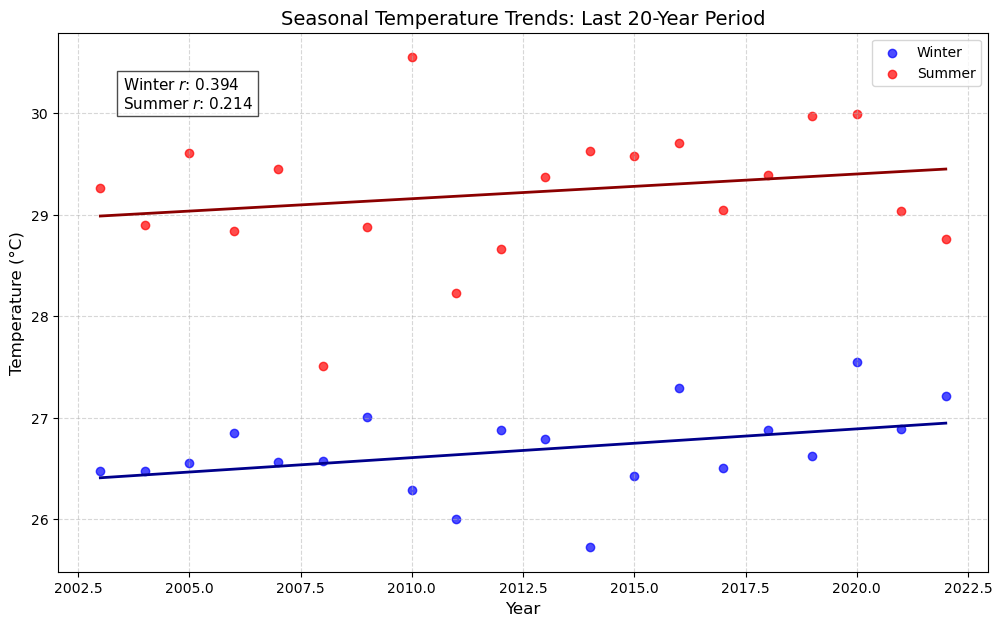

In [ ]:
# Plot for the last 20 years goes here

ax4 = None
# Define the subset for the last 20 years (indices 34 to 53)
last20 = data.loc[34:53]
fig, ax4 = plt.subplots(figsize=(12, 7))

# Scatter plots for the 20-year window
ax4.scatter(last20['Year'], last20['Jan mean'], color='blue', label='Winter', alpha=0.7)
ax4.scatter(last20['Year'], last20['May mean'], color='red', label='Summer', alpha=0.7)

# Calculate and include regression lines for the subset
# Winter regression (last 20 years)
slope_w20, intercept_w20 = np.polyfit(last20['Year'], last20['Jan mean'], 1)
ax4.plot(last20['Year'], slope_w20 * last20['Year'] + intercept_w20, color='darkblue', linewidth=2)

# Summer regression (last 20 years)
slope_s20, intercept_s20 = np.polyfit(last20['Year'], last20['May mean'], 1)
ax4.plot(last20['Year'], slope_s20 * last20['Year'] + intercept_s20, color='darkred', linewidth=2)

# Add axis labels, title, and legend
ax4.set_xlabel('Year', fontsize=12)
ax4.set_ylabel('Temperature (°C)', fontsize=12)
ax4.set_title('Seasonal Temperature Trends: Last 20-Year Period', fontsize=14)
ax4.legend()

# Add text displaying correlation coefficients for the 20-year period
text_info_20 = f'Winter $r$: {r_winter20:.3f}\nSummer $r$: {r_summer20:.3f}'
ax4.text(last20['Year'].min() + 0.5, last20['May mean'].max() - 0.5, text_info_20, 
         bbox=dict(facecolor='white', alpha=0.7), fontsize=11)

ax4.grid(True, linestyle='--', alpha=0.5)
plt.show()


*Figure 4.* The seasonal temperatures trend map from 2003 to 2022. Red plot represents summer, while the blue plot represents winter.

## Problem 3: Calculating a goodness-of-fit (3.5 points)

The final part of the exercise this week is to calculate a goodness-of-fit for the lines fit to the data in Problem 1. The idea here is to consider that we have an expected value of the temperature based on our least-squares regressions, and we can see how well those expected values fit within the standard deviation of the seasonal temperatures.

### Scores for this problem

**Your score on this problem will be based on following criteria**:

- Properly converting the goodness-of-fit formula to a Python function and adding that function to your `gdam_functions.py` script file
- Calculating goodness-of-fit values for summer and winter and for the two different time periods
- Including comments that explain what most lines in the code do
- Uploading your notebook and modified script file to your GitHub repository for this week's exercise

### Part 1: A goodness-of-fit function (1.5 points)

We can start by creating a function to calculate the goodness-of-fit. For this, you can use the reduced chi-squared equation,

\begin{equation}
  \Large
  \chi^{2} = \frac{1}{N} \sum \frac{(O_{i} - E_{i})^{2}}{\sigma_{i}^2}
\end{equation}

where $N$ is the number of ages, $O_{i}$ is the $i$th observed value, $E_{i}$ is the $i$th expected value, and $\sigma_{i}$ is the $i$th standard deviation.`

For this part you should:

- Create a function called `chi_squared` in your `gdam_functions.py` script file that can be used to calculate the reduced chi-squared value

In [ ]:
# Import your new function below using the format "from introqg_functions import chi_squared"
from gdam_functions import chi_squared


In [ ]:
# These visible tests with fake data should work
from unittest import TestCase
# Create a shortcut that works like the old one
assert_equal = TestCase().assertEqual

# Fake data
obs1 = np.array([1.1, 2.9, 2.6, 3.5, 5.7, 2.8])
exp1 = np.array([1.5, 2.4, 3.6, 1.5, 6.7, 2.6])
std1 = np.array([0.5, 1.4, 0.6, 1.5, 0.7, 1.0])

obs2 = np.array([1.8, 2.3, 2.2, 3.9, 5.5, 2.4])
exp2 = np.array([1.2, 2.0, 3.9, 1.7, 6.1, 2.9])
std2 = np.array([0.2, 0.4, 1.6, 2.5, 0.5, 0.3])

# Fake goodness-of-fit values
cs1 = chi_squared(obs1, exp1, std1)
cs2 = chi_squared(obs2, exp2, std2)

# Print results
print(f"Goodness-of-fit for dataset 1: {cs1:.4f}.")
print(f"Goodness-of-fit for dataset 2: {cs2:.4f}.")

# Check that the chi-squared function works
assert_equal(round(cs1, 4), 1.2340)
assert_equal(round(cs2, 4), 2.6139)

Goodness-of-fit for dataset 1: 1.2340.
Goodness-of-fit for dataset 2: 2.6139.


### Part 2: Calculating goodness-of-fit (2 points)

Next, we can calculate the goodness-of-fit for each point along our line and the corresponding observed seasonal mean temperaure. We will do this by first creating arrays of expected temperature values for each season and time period, and then calculating the goodness-of-fit between those expected values and the observed temperatures.

- Create 4 arrays that contain the expected temperature value for each year based on the equation for the regression lines calculated in Problem 1
    - The variables `exp_winter` and `exp_summer` can be used for all years, while `exp_winter20` and `exp_summer20` can be used for the last 20 years
- Calculate the goodness-of-fit between the expected values and the observed mean seasonal temperatures
    - The variables `gof_winter` and `gof_summer` can be used for all years, while `gof_winter20` and `gof_summer20` can be used for the last 20 years

In [ ]:
# Expected temperatures based on least-squares regression in Problem 1
exp_winter = B_winter * data['Year'] + A_winter
exp_summer = B_summer * data['Year'] + A_summer
exp_winter20 = B_winter20 * data['Year'] + A_winter20
exp_summer20 = B_summer20 * data['Year'] + A_summer20

# Goodness-of-fit values
gof_winter = chi_squared(data['Jan mean'], exp_winter, data['Jan std'])
gof_summer = chi_squared(data['May mean'], exp_summer, data['May std'])
gof_winter20 = chi_squared(data['Jan mean'].loc[34:53], exp_winter20, data['Jan std'].loc[34:53])
gof_summer20 = chi_squared(data['May mean'].loc[34:53], exp_summer20, data['May std'].loc[34:53])

# Imports the 'mean' function from gdam_functions
from gdam_functions import mean

In [ ]:
# This test should work
print(f"My mean expected winter temperature: {mean(exp_winter):.4f}. Expected value: 26.6489.")


My mean expected winter temperature: 26.6490. Expected value: 26.6489.


In [ ]:
# This test should work
print(f"My summer (all years) goodness-of-fit: {gof_summer:.4f}. Expected value: 0.5692.")


My summer (all years) goodness-of-fit: 0.5692. Expected value: 0.5692.


In [ ]:
# Run this cell to print all of your calculated goodness-of-fit values
print(f"My winter goodness-of-fit values:\n    All years:     {gof_winter:.4f}\n    Last 20 years: {gof_winter20:.4f}\n")
print(f"My summer goodness-of-fit values:\n    All years:     {gof_summer:.4f}\n    Last 20 years: {gof_summer20:.4f}")

My winter goodness-of-fit values:
    All years:     0.3890
    Last 20 years: 0.2378

My summer goodness-of-fit values:
    All years:     0.5692
    Last 20 years: 0.8161


## Summary questions for Exercise 2 (2 points; 0.5 points each)

Answer the questions below in a few sentences.

1. Based on the least-squares regressions calculated in Problem 1, how have summer and winter temperatures changed in Mactan over the time 1966-2022? Is the trend similar for both seasons? What about when you consider only the data over the last 20 years? Do you have any first-hand experience that relates to these temperature trends? If so, what?
2. Based on the calculation of the correlation coefficients in Problem 2, how well does it seem the data are fit by a line? Are there any significant differences between seasons or time periods in the calculated $r$ values?
3. Looking at the goodness-of-fit values calculated in Problem 3, how well does it appear the data are fit by a regression line? Do you see differences between seasons ot time period considered? 
4. Comparing the calculated $\chi^{2}$ values from Problem 3 to the $r$ values in Problem 2, what differences do you see in the numbers between seasons and/or time periods? Can you think of reasons why the $r$ and $\chi^{2}$ values might differ in terms of their relative values in each season/time period? How are the $r$ and $\chi^{2}$ values different in terms of what they measure?

**ANSWERS:**

1. **for edit** 
*Over the long-term period from 1966 to 2022, temperatures in Mactan have shown a gradual warming trend in both seasons, though winter temperatures rose roughly four times faster than those in the summer. When narrowing the focus to the last 20 years, this warming significantly accelerated and became more synchronized, with both seasons now increasing at a much higher and more comparable rate. These trends likely reflect a combination of global climatic shifts and localized effects like the Urban Heat Island effect caused by the rapid development around Mactan International Airport. This increase in heat is often palpable during El Niño years, such as the notable temperature spike seen in 2010, which matches historical records of severe heat events in the Philippines.*

Observing the trends, the temperature in Mactan both seasons had a gradual warming trend. In contrast, the winter season was observed to have increased faster. Meanwhile, in the last 20 yrs, the increase in temperature became more faster. While I do not have any first hand experiences, my parents note significantky warmer temperatures in the more recent years compared to their childhood. 


2. Comparing the plots of the summer and winter seasons, it is observed that temperature during summer is generally nearer to the line, unlike with the values during winter, which appears to be more scattered.
3. It appears that the data for winter fits a regression line better than summer data. There is a significant difference between periods or time period considered. For all years considered, there is a lower chi-squared value for winter compared to summer. When only last 20 years are considered, the chi-squared value is still lower for winter than summer. This means that for winter data, there is generally less discrepanmcy between expected and observed values compared to summer data. 
4.  Compared to the r value of summer, its chi-squared value is significantly higher. For winter, both r values and chi-squared values are both relatively low. It might be that the chi-squared was higher for summer because the sample size became smaller therefore affceting the discrepancy between the expected and observed value. The r value The r value measures the strength of the relationship between two factors while the chi-squared value measures the deviation from observed and expected values. 